# Imports

In [248]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import cv2

# Methods

In [251]:
def apply_fourier_transform(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = np.log(np.abs(f_shift) + 1) # 20 * np.log(np.abs(f_shift) + 1)
    return magnitude_spectrum, f_shift
    

# Parameters

In [252]:
path_assets = PROJECT_DIR / 'assets'
path_imgs_atv = path_assets / "atv02_lista02-assets"

# Questão 09

## a) uma solução aplicada no domínio da frequência

### 1.1) Leitura

In [309]:
img_names = ["cameraman.png", "cameraman_pattern.png"]
# img = cv2.imread(path_assets / "atv02_lista02-assets" / 'cameraman_pattern.png', cv2.IMREAD_GRAYSCALE)
imgs = {
    i.split(".")[0]: cv2.imread(path_imgs_atv / i, cv2.IMREAD_GRAYSCALE) for i in img_names
}

# imgs["cameraman_pattern_cut"] = imgs["cameraman_pattern"][0:150, 0:200]

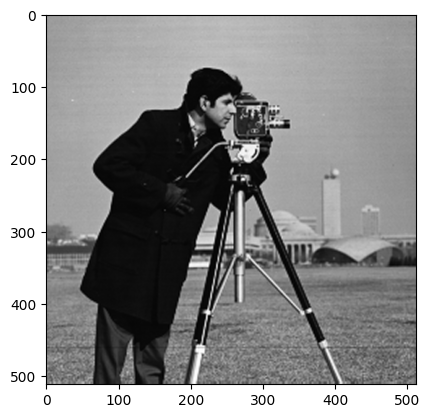

In [310]:
# Aplicando a transformada de Fourier
dft = cv2.dft(np.float32(imgs["cameraman"]), flags=cv2.DFT_COMPLEX_OUTPUT)

# Deslocando o zero-frequência para o centro
dft_shift = np.fft.fftshift(dft)
dft_ishift = np.fft.ifftshift(dft_shift)
img_back = cv2.idft(dft_ishift)
img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])
plt.imshow(img_back, cmap='gray')

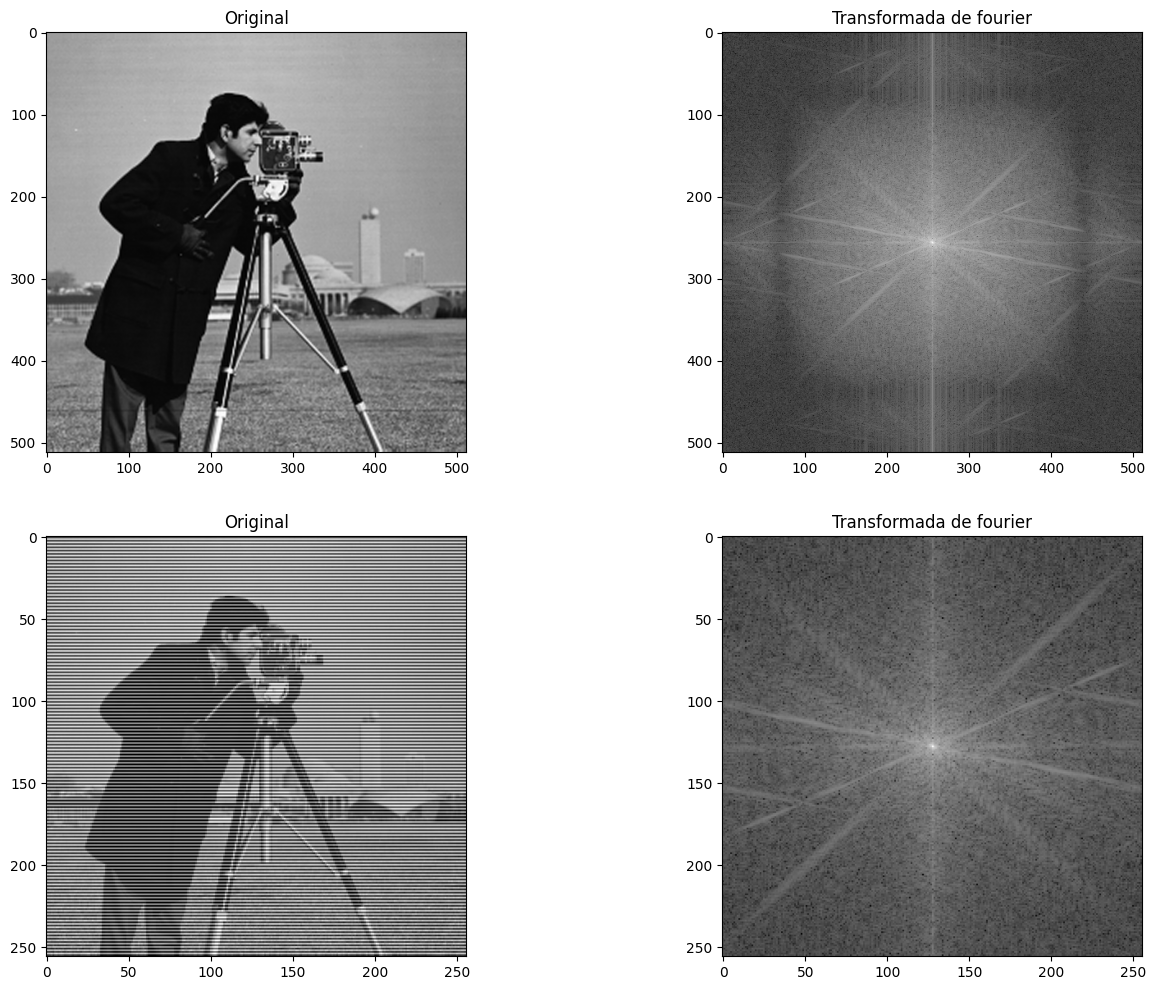

In [311]:
fourier = {
    name: {
        "tft": apply_fourier_transform(img)[1],
        "spectrum": apply_fourier_transform(img)[0]
    } for name, img in imgs.items()
}
# Mostrar imagem resultante
fig, ax = plt.subplots(len(fourier), 2, figsize=(16, 12))
for _ax, name in zip(ax, fourier.keys()):
    _ax[0].imshow(imgs[name], cmap='gray')
    _ax[0].set_title('Original')
    _ax[1].imshow(fourier[name]["spectrum"].astype(float), cmap='gray')
    _ax[1].set_title('Transformada de fourier')
    #_ax[0].axis('off')
    #_ax[1].axis('off')
plt.show()


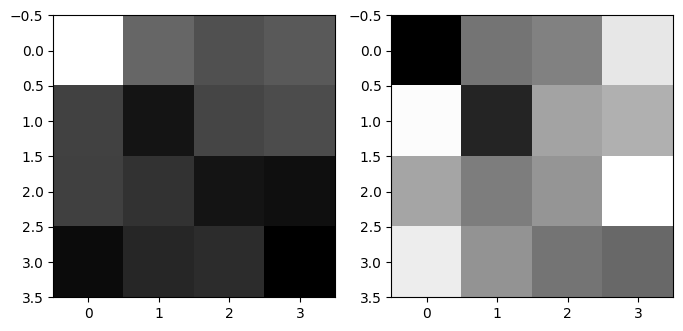

In [312]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(fourier["cameraman"]["spectrum"][:4, :4], cmap='gray')
ax[1].imshow(fourier["cameraman_pattern"]["spectrum"][:4, :4], cmap='gray')

In [261]:
imgs["cameraman_pattern"][:4, :4]

array([[212, 214, 213, 212],
       [ 69,  66,  68,  68],
       [212, 214, 213, 212],
       [ 69,  66,  68,  68]], dtype=uint8)

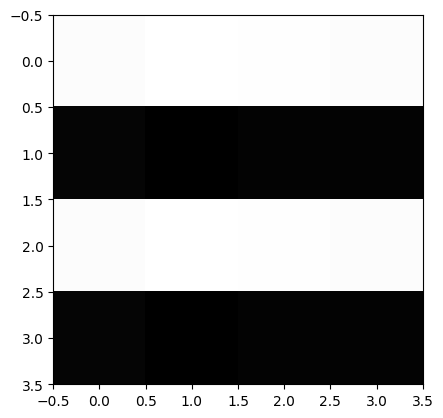

In [259]:
plt.imshow(imgs["cameraman_pattern"][:4, :4], cmap='gray')

In [237]:
recorte = imgs["cameraman_pattern"]
for i in range(1, recorte.shape[0], 2):
    print(recorte[i]) 
    recorte[i] = recorte[i - 1]#[np.median(recorte)] * recorte.shape[1]
    # recorte[i] = [255] * recorte.shape[1]

[69 66 68 68 68 69 68 68 68 69 67 67 69 68 69 68 71 69 69 68 70 70 69 70
 69 70 71 70 71 71 73 71 70 71 69 70 71 72 72 71 71 70 73 73 73 73 73 73
 73 73 73 75 73 72 74 74 73 72 73 73 73 73 75 72 74 75 75 75 76 76 77 76
 77 76 76 78 78 78 77 77 78 78 78 78 79 78 78 79 78 79 79 78 77 78 79 79
 79 78 77 78 76 79 79 79 81 80 80 79 78 79 79 80 79 79 79 78 79 80 79 80
 80 79 81 79 81 81 80 80 78 80 78 79 80 79 78 80 79 79 79 79 80 79 79 79
 78 80 79 79 77 78 78 75 78 77 78 76 78 78 78 77 78 75 76 77 78 75 76 75
 76 75 75 75 75 75 77 75 75 75 73 74 73 73 74 74 74 74 74 73 74 73 73 72
 72 72 72 72 72 72 72 72 74 73 71 74 73 72 73 73 72 72 71 71 73 71 70 70
 72 69 69 70 68 69 72 70 69 69 69 69 68 69 68 67 69 67 69 69 67 67 67 66
 66 68 67 67 68 66 67 67 68 67 68 67 67 66 67 66]
[69 66 68 68 68 69 68 68 68 69 67 67 69 68 69 68 71 69 69 68 70 70 69 70
 69 70 71 70 71 71 73 71 70 71 69 70 71 72 72 71 71 70 73 73 73 73 73 73
 73 73 73 75 73 72 74 74 73 72 73 73 73 73 75 72 74 75 75 75 76 76 77 76
 

In [226]:
recorte[:3, :3]

array([[212, 214, 213],
       [128, 128, 128],
       [212, 214, 213]], dtype=uint8)

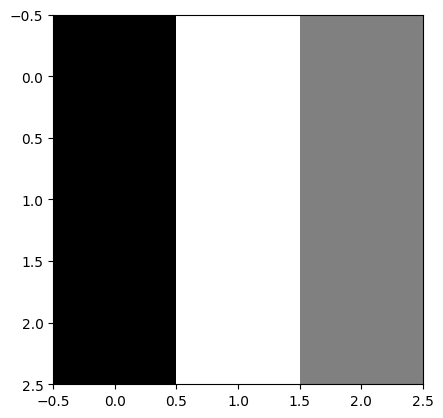

In [238]:
plt.imshow(recorte[:3, :3] / 256 , cmap='gray',)

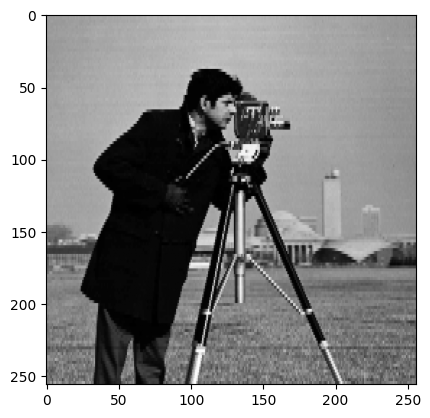

In [239]:
plt.imshow(recorte, cmap="gray")

In [270]:
magnitude_spectrum.shape#[125:129, 125:129]

(256, 256)

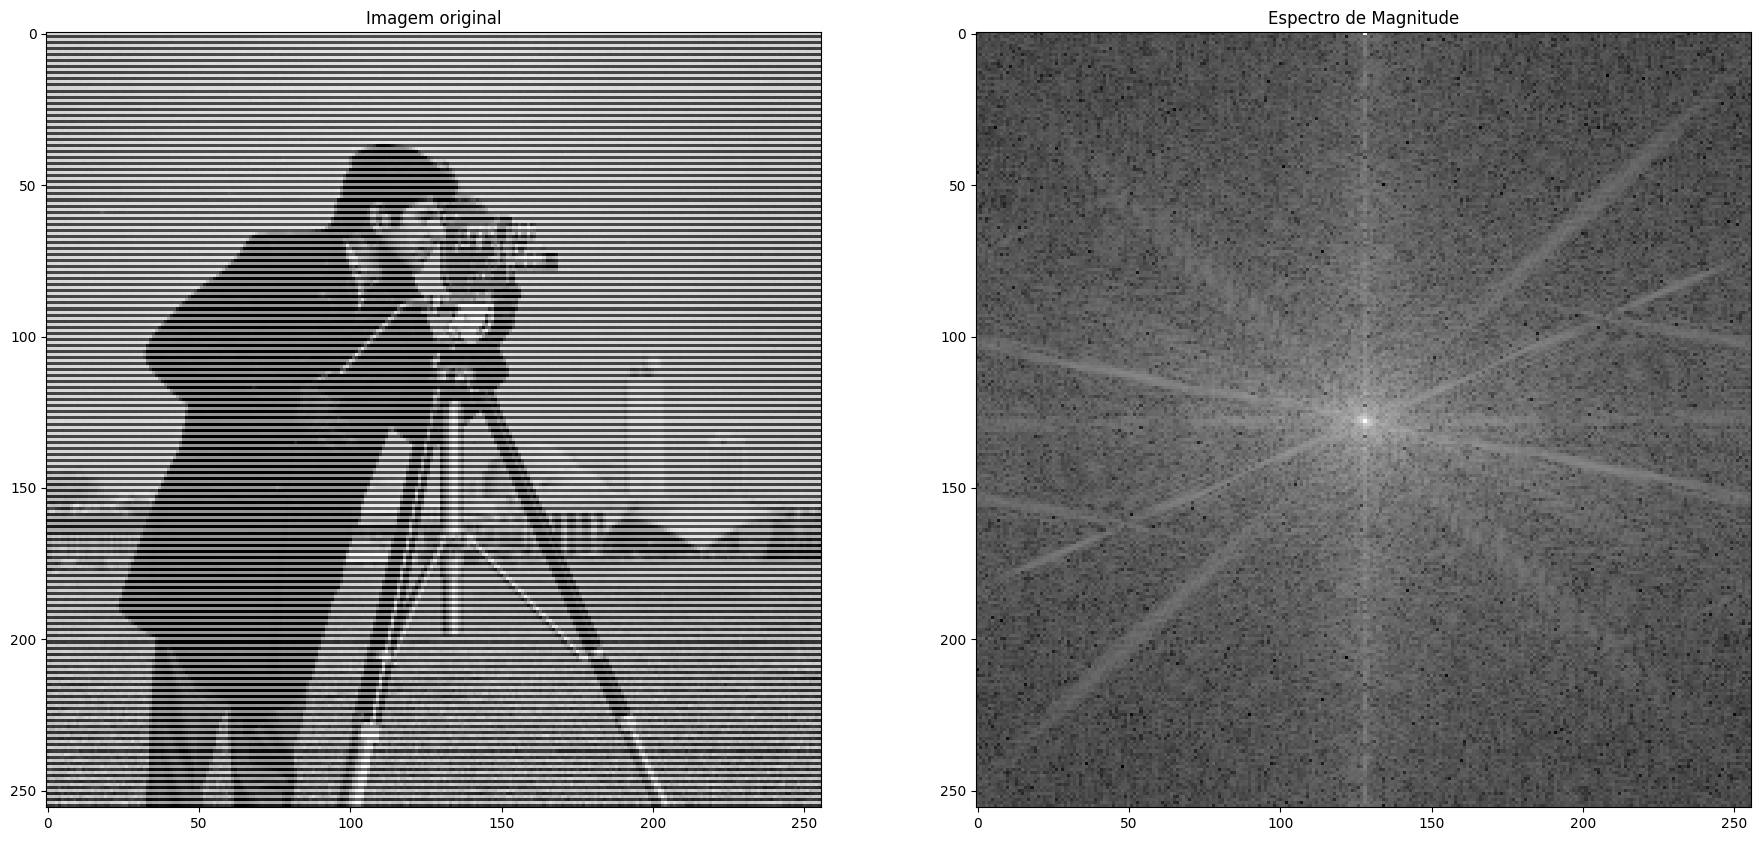

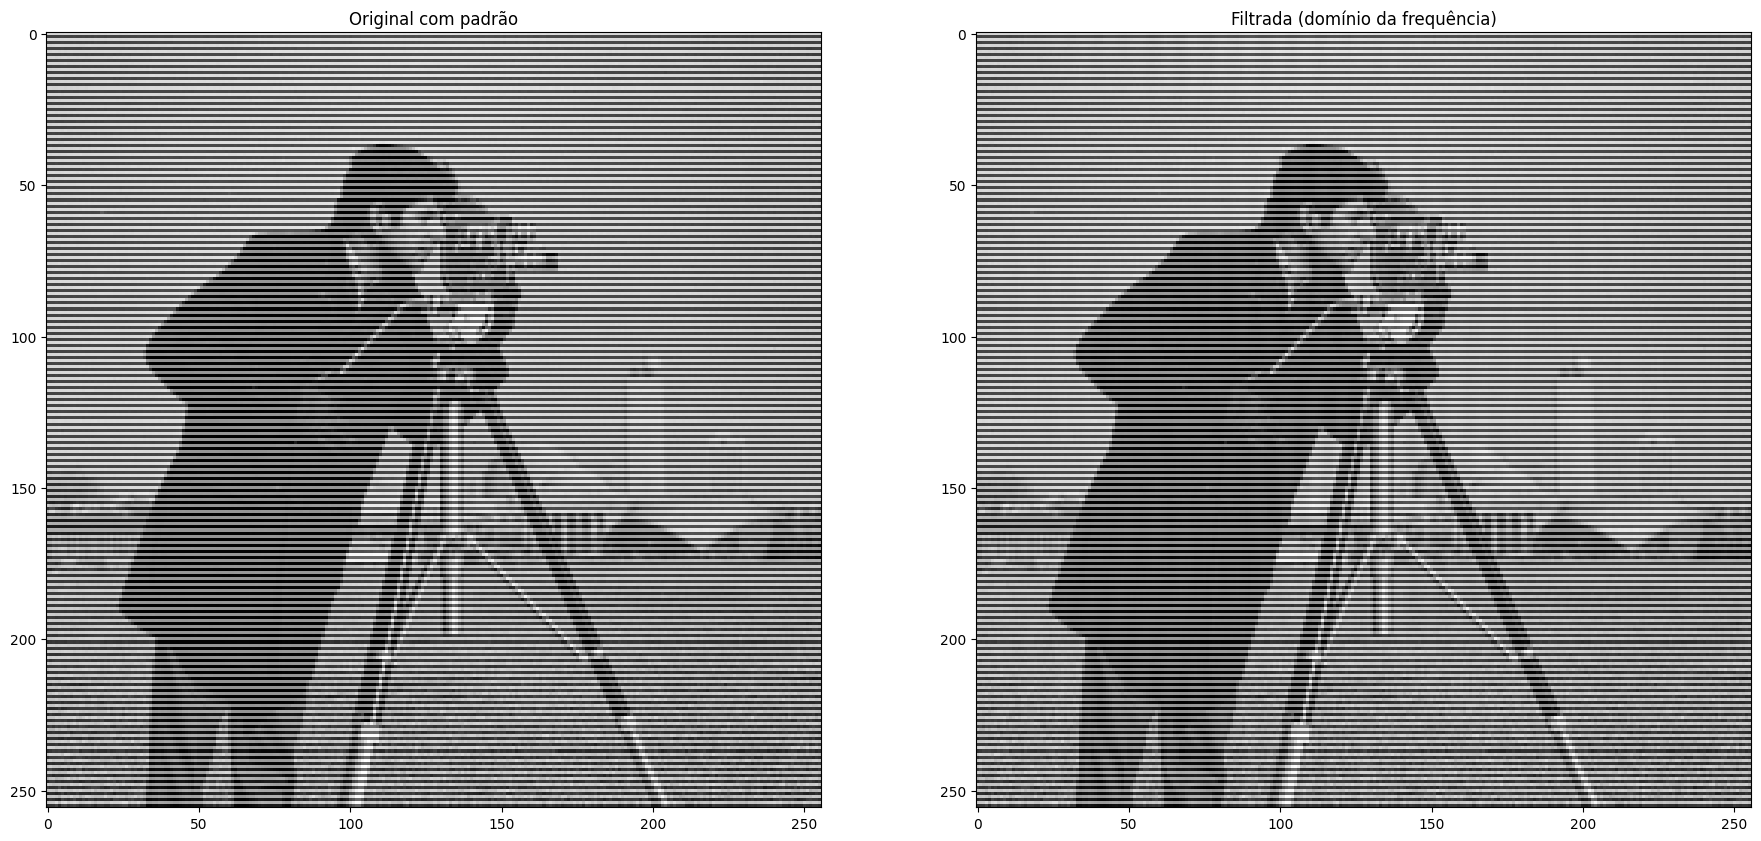

In [266]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carregar a imagem com padrão
img = imgs["cameraman_pattern"].astype(np.float32)

# 1. Aplicar FFT
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = np.log(1 + np.abs(fshift))

# 2. Visualizar espectro de magnitude para identificar os picos
plt.figure(figsize=(22, 18))
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Imagem original')
plt.subplot(122), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title('Espectro de Magnitude')
plt.show()

# 3. Criar uma máscara para remover os picos indesejados
rows, cols = img.shape
crow, ccol = rows // 2 , cols // 2

# Cria uma máscara com 1s (deixa tudo) e 0s nos pontos a serem removidos
mask = np.ones((rows, cols), np.uint8)
# Exemplo: remover pequenas regiões em torno de onde os picos aparecem
mask[crow-3:crow+3, ccol-30:ccol-25] = 0
mask[crow-3:crow+3, ccol+25:ccol+30] = 0

# 4. Aplicar a máscara
fshift_filtered = fshift * mask

# 5. Transformada inversa
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Mostrar imagem final
plt.figure(figsize=(22, 18))
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Original com padrão')
plt.subplot(122), plt.imshow(img_filtered, cmap='gray'), plt.title('Filtrada (domínio da frequência)')
plt.show()


In [306]:

mask = np.ones_like(fshift, dtype=np.uint8)

# Tentar remover regiões diagonais e verticais perto de onde aparecem os riscos
# Ajuste esses valores manualmente de acordo com os picos que você vê

# Exemplo: eliminar linha vertical passando pelo centro (típica de padrão horizontal)
mask[:, 127:129] = 0  # ajustado ao redor do centro
# Exemplo: eliminar algumas diagonais — cuidado para não destruir a imagem
# for offset in range(0, 41, 1):
#     if offset == 0:
#         continue
#     mask[128+offset, :] = 0
#     mask[:, 128+offset] = 0


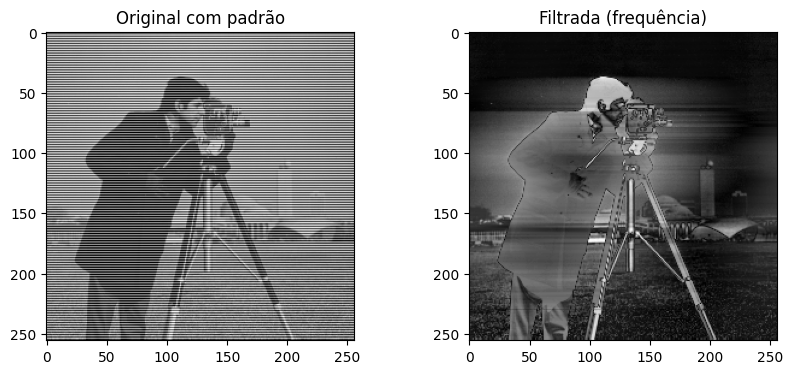

In [307]:
fshift_filtered = fshift * mask
# Transformada inversa
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Exibir o resultado
plt.figure(figsize=(10, 4))
plt.subplot(121), plt.imshow(imgs["cameraman_pattern"], cmap='gray'), plt.title("Original com padrão")
plt.subplot(122), plt.imshow(img_filtered, cmap='gray'), plt.title("Filtrada (frequência)")
plt.show()

/tmp/ipykernel_844/3742742391.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  coords = plt.ginput(n=0, timeout=0)  # permite clicar nos pontos brilhantes


KeyboardInterrupt: 

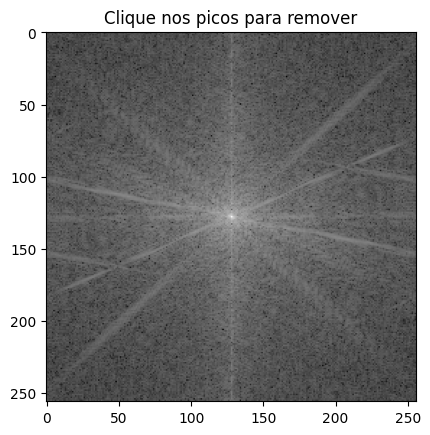

In [308]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = imgs["cameraman_pattern"].astype(np.float32)

# FFT
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = np.log(1 + np.abs(fshift))

# Visualizar espectro
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Clique nos picos para remover")
coords = plt.ginput(n=0, timeout=0)  # permite clicar nos pontos brilhantes
plt.close()
print("Coordenadas selecionadas:", coords)

# Criar máscara e remover círculos nas posições clicadas
mask = np.ones_like(img, dtype=np.uint8)
for (x, y) in coords:
    cv2.circle(mask, (int(x), int(y)), 5, 0, -1)  # bolhas de raio 5

# Aplicar a máscara no espectro
fshift_filtered = fshift * mask

# Inversa
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Mostrar resultado
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title("Original")
plt.subplot(122), plt.imshow(img_filtered, cmap='gray'), plt.title("Filtrada")
plt.show()


## b) uma solução aplicada no domínio espacial